# Validation Strategy

During Exploratory Data Analysis we found out the following facts:
- Train span: 182.00 days (`DT` 86,400 → 15,811,131)
- Test span: 183.00 days (`DT` 18,403,224 → 34,214,345)
- **Gap between end of train and start of test: exactly 30.00 days**
- Total combined span: 395 days

There's a full month of unseen time between the last training transaction and the first test transaction. Any local validation scheme that doesn't reproduce this gap may fail to be efficient and trustfull.

## Chosen Strategy: Single Time-Based Holdout Split with a 30-Day Purge Gap

**Visuality**: [--------------- Train (up to day D) ---------------] -> 30-day Gap -> [Validation]

**Single Time-Based Holdout Split (primary, for fast iteration)**  
Instead of a default and simple 80/20 cut, we can mirror a 30-day gap as it is in train/test.
* Training Set (Days 1 to 122): The first ~4 months of data are used exclusively for model training.
* Purge Gap (Days 123 to 152): The next 30 days are completely dropped from both training and validation.
* Validation Set (Days 153 to 182): The final 30 days of the available training data serve as the local validation benchmark.

## Motivation
* **Simulating the real test environment**: A local validation scheme that does not reproduce this blind spot of 30-day gap will fail to measure how well the model generalizes across temporal drift.
* **Preventing temporal leakage**: Standard random K-fold Cross-Validation allows the model to train on future data to predict the past, leading to artificially inflated local scores. This strict chronological cutoff guarantees that no future information leaks into the training phase.
* **Maximazing data efficiency**: Implementing a full time-series K-fold cross-validation with 30-day gaps would starve the early folds of historical context (e.g., training a fold on only 60 days of data). A single holdout split ensures the model trains on a sufficiently deep historical baseline (4 months) to learn user behaviors, seasonal trends, overall dynamics.

## Reasons for High Correlation with Leaderboard results:
* Strict chronological boundaries and timeline
* Time-Invariant feature engineering

## Reasons for Low Correlation with Leaderboard results:
* Genuine concept drift beyond 30 days — if fraud patterns shift meaningfully within that month, we can no longer accurately predict the results.
* The risk of missing out of important patterns in month 5 (30-day gap we created)

# Adversarial Validation

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import gc
import warnings


pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip -d data/

Saving kaggle.json to kaggle (2).json
ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/test_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/test_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/train_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/train_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
def reduce_mem_usage(df, verbose=True):
    """Safely downcasts numeric columns without overflow or precision loss."""
    start_mem = df.memory_usage().sum() / 1024**2

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        for col in df.columns:
            col_type = df[col].dtype

            # Skip objects, categoricals, and datetimes
            if col_type != object and col_type.name != 'category' and not pd.api.types.is_datetime64_any_dtype(df[col]):
                c_min = df[col].min()
                c_max = df[col].max()

                # Skip columns containing infinite values to prevent overflow errors
                if np.isinf(c_min) or np.isinf(c_max):
                    continue

                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
                else:
                    # Keep float32 as minimum target for stable training in sklearn/models
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
                    else:
                        df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

*Note: The code above was written with a help from Gemini to save some memory and not to have crashes*

In [14]:
print("Loading Train...")
train_tx = pd.read_csv('data/train_transaction.csv')
train_id = pd.read_csv('data/train_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')

del train_tx, train_id
gc.collect()

train = reduce_mem_usage(train)

print("\nLoading Test...")
test_tx = pd.read_csv('data/test_transaction.csv')
test_id = pd.read_csv('data/test_identity.csv')

test = test_tx.merge(test_id, on='TransactionID', how='left')

del test_tx, test_id
gc.collect()

test = reduce_mem_usage(test)

print(f"\nFinal Train shape: {train.shape}")
print(f"Final Test shape: {test.shape}")

Loading Train...
Memory usage decreased to 1044.70 MB (46.6% reduction)

Loading Test...
Memory usage decreased to 895.89 MB (46.5% reduction)

Final Train shape: (590540, 434)
Final Test shape: (506691, 433)


In [15]:
SAMPLE_SIZE = 50000

# common columns excluding target and ID proxies
common_cols = [c for c in train.columns if c in test.columns and c not in ['isFraud', 'TransactionID']]

numeric_cols = train[common_cols].select_dtypes(include=['number']).columns.tolist()

# sample rows and cast to float32
s_train = train[numeric_cols].sample(n=min(SAMPLE_SIZE, len(train)), random_state=42).astype(np.float32)
s_test = test[numeric_cols].sample(n=min(SAMPLE_SIZE, len(test)), random_state=42).astype(np.float32)

adv_df = pd.concat([s_train, s_test], ignore_index=True).copy()

# build target array directly without modifying adv_df columns
y_adv = np.array([0] * len(s_train) + [1] * len(s_test))

del s_train, s_test
gc.collect()

def run_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # Preprocessing
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    del X_imputed
    gc.collect()

    clf = LogisticRegression(max_iter=1000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # n_jobs=1 prevents parallel worker memory spikes
    scores = cross_val_score(clf, X_scaled, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


# baseline WITH TransactionDT
cols_with_dt = numeric_cols

# EXCLUDE TransactionDT, ALL raw D-columns, and DT derivatives
time_leaking_cols = ['TransactionDT', 'DT_day'] + \
                     [c for c in numeric_cols if c.startswith('D') and not c.endswith('_detrended')]

cols_no_time = [c for c in numeric_cols if c not in time_leaking_cols]

# experiments
scores_with_dt = run_adversarial_validation(cols_with_dt, label="(including TransactionDT)")
scores_no_time = run_adversarial_validation(cols_no_time, label="(excluding TransactionID, Time & ALL Raw D-Cols)")

=== Adversarial Validation (including TransactionDT) ===
Mean AUC: 1.0000 (+/- 0.0000)
=== Adversarial Validation (excluding TransactionID, Time & ALL Raw D-Cols) ===
Mean AUC: 0.7235 (+/- 0.0022)


*Note: Gemini and Claude were used to help write a correct strcture for Adversarial Validation and how it should look like.*

Top 15 features driving Train/Test separation (excluding time leakage):
C12     10.404209
C11     10.367220
C4       8.890740
C7       7.617776
V159     4.245861
C9       3.279273
V150     2.631828
C6       2.102463
C14      1.768870
V165     1.642709
V71      1.365924
C8       1.247218
V168     1.234676
C2       1.152971
V151     1.098458
dtype: float64


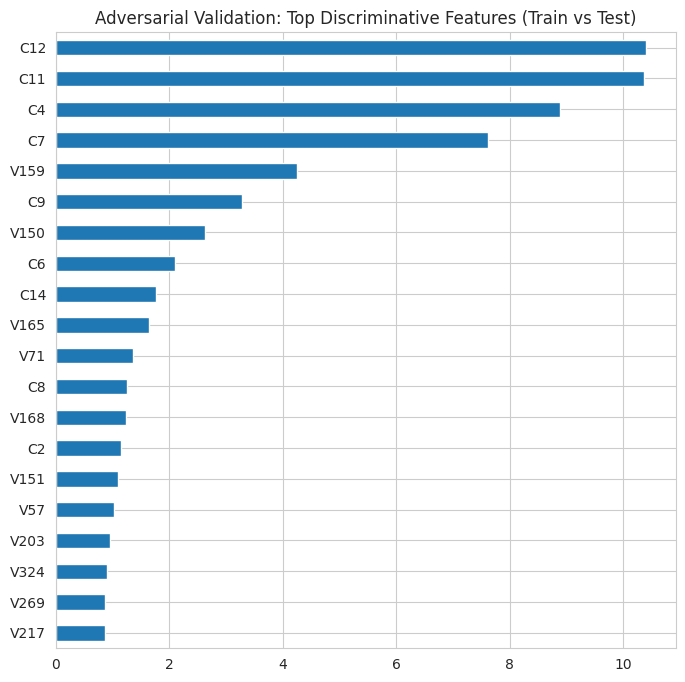

In [16]:
# ── Feature importance: ──
X_full = adv_df[cols_no_time].copy()
X_imputed = SimpleImputer(strategy='median').fit_transform(X_full)
X_scaled = StandardScaler().fit_transform(X_imputed)

clf_full = LogisticRegression(max_iter=1000, random_state=42)
clf_full.fit(X_scaled, y_adv)

importance = pd.Series(np.abs(clf_full.coef_[0]), index=cols_no_time).sort_values(ascending=False)
print("Top 15 features driving Train/Test separation (excluding time leakage):")
print(importance.head(15))

importance.head(20).plot(kind='barh', figsize=(8,8))
plt.title('Adversarial Validation: Top Discriminative Features (Train vs Test)')
plt.gca().invert_yaxis()
plt.show()